In [4]:
%matplotlib widget
import scipp as sc
import tof
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import scippneutron as scn
import subprocess
import mcstasscript as ms
from ESS_MIRACLES_v10_2_generated import make
from pathlib import Path
from cycler import cycler
import shutil

Hz = sc.Unit('Hz')
deg = sc.Unit('deg')
meter = sc.Unit('m')
ESS_COLORS = {
    "cyan":[ 0, 153/255, 220/255],
    "navy":[0, 51/255, 102/255],
    "grass":[ 153/255, 190/255, 0],
    "forest":[0, 102/255, 70/255],
    "orange":[ 255/255, 125/255, 0],
    "purple":[130/255, 20/255, 130/255]
}
plt.rcParams["axes.prop_cycle"] = cycler(color=[ESS_COLORS[key] for key in ESS_COLORS])

In [5]:
source = tof.Source(facility='ess',pulses=5,neutrons=10_000_000)

In [6]:
names=['PWD1','PWD2','PS','FO']
distances=[7.7,7.75,8.3,54.5]
openingangles=[12,12,15,105]


In [7]:
def acceptanceDiagram(chops):
    chopperdict={}
    for chop in chops:
        octimes=chop.open_close_times()
        chopperdict.update({chop.name: scn.tof.chopper_cascade.Chopper(
            distance=chop.distance,
            time_open=sc.to_unit(octimes[0], unit='s'),
            time_close=sc.to_unit(octimes[1], unit='s')
        )})
    choppers = sc.DataGroup(chopperdict)
    frames = scn.tof.chopper_cascade.FrameSequence.from_source_pulse(
        time_min=sc.scalar(0.0, unit='ms'),
        time_max=sc.scalar(4.0, unit='ms'),  # ESS pulse is 3 ms, but it has a tail
        wavelength_min=sc.scalar(0.0, unit='angstrom'),
        wavelength_max=sc.scalar(10.0, unit='angstrom'),
    )
    frames = frames.chop(choppers.values())
    at_sample = frames.propagate_to(sc.scalar(162.5, unit='m'))
    return at_sample

def neutron_energy_ueV(lambda_A):
    """Neutron energy in µeV from wavelength in Å."""
    return 81804.0 / (lambda_A ** 2)

In [8]:
saveddata={'frequencyCH1':[],
           'frequencyCH4':[],
           'dE':[],
           'DE':[],
           'intflux':[]
          }
if not os.path.exists('overview'):
    os.makedirs('overview')
texfile="overview/summary.tex"
with open(texfile, "w") as f:
    f.write(r"\documentclass{standalone}\usepackage{multirow}\usepackage{graphicx}\begin{document}	\begin{tabular}{l|lll|lllllll}Settings&common Delay [s]&speed&individual delay[deg]&$\hbar\omega$ [$\mu$eV]&Phase&Frequency&Time-Distance Diagram&Wavelength distribution&McStas Distribution&McStas TOF\\\hline")
ACdiagrams=[]
for condition in range(1,10):
    analysisfilered=f'condition{condition}/data reduction/reduction_Files/Instrumentparameters_reduced.txt'
    analysisfile=f'condition{condition}/data reduction/reduction_Files/Instrumentparameters.txt'
    shutil.copy(analysisfilered,analysisfile)
    folder=f'condition{condition}/' 
    if not os.path.exists(folder):
        os.makedirs(folder)
    chopperfile=f'condition{condition}/choppersettings.cfg'
    with open(chopperfile, "w") as f:
        f.write(r"    #x[m]   y[m]  dist[m]    radius[m]  nu[Hz]     nslit  theta_0    yheight[m]     phase delay[s]"+'\n')
    #define chopper settings
    if condition==1:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-35])
        freq=np.array([14,14,14,7])
        vel=626.8#m/s
    elif condition==211:#not centered
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,25])
        freq=np.array([14,14,14,14])
        vel=631.8#m/s
    elif condition==2:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-25.5])
        freq=np.array([14,14,14,14])
        vel=650#m/s
    elif condition==311:#not centered
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-50])
        freq=np.array([28,14,14,7])
        vel=631.8#m/s
    elif condition==3:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-50])
        freq=np.array([28,14,14,7])
        vel=614.4#m/s
    elif condition==411:#not centered
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-10])
        freq=np.array([28,14,14,14])
        vel=631.8#m/s
    elif condition==4:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-10])
        freq=np.array([28,14,14,14])
        vel=677.6#m/s
    elif condition==5:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-30])
        freq=np.array([56,14,14,14])
        vel=645.5#m/s
    elif condition==6:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-30])
        freq=np.array([112,14,14,14])
        vel=642.8#m/s
    elif condition==7:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-35])
        freq=np.array([168,14,14,14])
        vel=635.2#m/s
    elif condition==811:#not centered
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-30])
        freq=np.array([224,14,14,14])
        vel=631.8#m/s
    elif condition==8:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,0,-30])
        freq=np.array([224,14,14,14])
        vel=640.5#m/s
    elif condition==9:
        directions=[tof.Clockwise,tof.AntiClockwise,tof.Clockwise,tof.Clockwise]
        delay=np.array(0.001712598923710033)
        individualdelay=np.array([0,12,-5,-65])
        freq=np.array([224,224,7,14])
        vel=590#m/s
    saveddata['frequencyCH1'].append(freq[0])
    saveddata['frequencyCH4'].append(freq[3])
    #create now tof diagrams
    traveltime=np.array(distances)/vel# s
    phases=(traveltime+delay)*360*freq+individualdelay #deg
    choppers=[]
    for name,phase,distance,angle,direction,frequence,hi in zip(names,phases,distances,openingangles,directions,freq,[0,1,2,3]):
        #print(name,phase,distance,angle,direction)
        choppers.append(tof.Chopper(
                frequency=frequence * Hz,
                open=sc.array(
                    dims=['cutout'],
                    values=[0],
                    unit='deg',
                ),
                close=sc.array(
                    dims=['cutout'],
                    values=[angle],
                    unit='deg',
                ),
                direction=direction,
                phase=phase * deg,
                distance=distance * meter,
                name=name,
            ))
    detectors = [
        tof.Detector(distance=162.5 * meter, name='sample'),
    ]
    model = tof.Model(source=source, choppers=choppers, detectors=detectors)
    res = model.run()
    fig=res.plot(visible_rays=10000,blocked_rays=10000)
    fig.fig.savefig(folder+f'TOF-Distance.pdf')
    fig2=res.detectors['sample'].wavelength.data.hist(wavelength=500).plot(xmin=4.5,xmax=10)
    fig2.fig.savefig(folder+f'WL.pdf')
    
    #create acceptance diagram
    at_sample=acceptanceDiagram(choppers)
    ACdiagrams.append(at_sample)
    acdiafig=at_sample.draw()
    acdiafig[0].savefig(folder+'AcceptanceDiagram.pdf')
    plt.close('all')
    lbda=at_sample[-1].subframes[0].wavelength.values
    hw=neutron_energy_ueV(lbda)-2080
    #write summary and chopper files for mcstas
    for name,phase,distance,angle,direction,frequence,hi in zip(names,phases,distances,openingangles,directions,freq,[0,1,2,3]):
        if direction==tof.Clockwise:
            dirfac=1
        else:
            dirfac=-1
        with open(texfile, "a") as f:
            if hi==0:
                if os.path.isfile(f"condition{condition}" +r"/between_guide_and_sample_wvl.pdf"):
                    mcstasfigure=r"\multirow{4}{*}{\includegraphics[width=.3\textwidth]{../condition"+f"{condition}" +r"/between_guide_and_sample_wvl.pdf}}&"+r"\multirow{4}{*}{\includegraphics[width=.3\textwidth]{../condition"+f"{condition}" +r"/tof_BGAS.pdf}}"
                else:
                    mcstasfigure=''
                f.write(r"\hline\multirow{4}{*}{"+f"{condition}"+r"}&\multirow{4}{*}{"+f"{delay}"+
                        r"}&\multirow{4}{*}{"+f"{vel}"+"}"+f"&{individualdelay[hi]}&"+r"\multirow{4}{*}{"+
                        f"[{min(hw)},{max(hw)}]"+"}"+f"&{phase}&{dirfac*frequence}"+r"&\multirow{4}{*}{\includegraphics[width=.5\textwidth]{../condition"+
                        f"{condition}" +r"/TOF-Distance.pdf}}"+r"&\multirow{4}{*}{\includegraphics[width=.3\textwidth]{../condition"+f"{condition}" +r"/WL.pdf}}&"+
                        mcstasfigure+r"\\[1em]"+"\n")
            else:
                f.write(f"&&&{individualdelay[hi]}&&{phase}&{dirfac*frequence}"+r"&&\\[1em]"+"\n")
        if hi==3:
            height=0.15
        else:
            height=0.1
        with open(chopperfile,"a") as f:
            f.write(f'    0.00    0.00  0.00       0.35    {dirfac*frequence}    1.0    {angle}    {height}     {phase}'+'\n')
        #write chopper files for analysis
        
        print(hi)
        with open(analysisfile,"a") as f:
            f.write(f'chopper{hi+1}_phase:{phase}'+'\n')
            f.write(f'chopper{hi+1}_speed:{frequence}'+'\n')
            f.write(f'chopper{hi+1}_distance:{distance}'+'\n')
with open(texfile, "a") as f:
    f.write(r"\end{tabular}\end{document}")

0
1
2
3
0
1
2
3
0
1
2
3
0
1
2
3
0
1
2
3
0
1
2
3
0
1
2
3
0
1
2
3
0
1
2
3


In [9]:
#compile summary
subprocess.run(
    ["pdflatex", "-interaction=nonstopmode", "summary.tex"],
    cwd="overview",
    check=True
)

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./summary.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/standalone/standalone.cls
Document Class: standalone 2025/02/22 v1.5a Class to compile TeX sub-files stan
dalone
(/usr/local/texlive/2025/texmf-dist/tex/latex/tools/shellesc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/generic/iftex/ifluatex.sty
(/usr/local/texlive/2025/texmf-dist/tex/generic/iftex/iftex.sty))
(/usr/local/texlive/2025/texmf-dist/tex/latex/xkeyval/xkeyval.sty
(/usr/local/texlive/2025/texmf-dist/tex/generic/xkeyval/xkeyval.tex
(/usr/local/texlive/2025/texmf-dist/tex/generic/xkeyval/xkvutils.tex
(/usr/local/texlive/2025/texmf-dist/tex/generic/xkeyval/keyval.tex))))
(/usr/local/texlive/2025/texmf-dist/tex/latex/standalone/standalone.cfg)
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Doc

CompletedProcess(args=['pdflatex', '-interaction=nonstopmode', 'summary.tex'], returncode=0)

In [10]:
def draw_polygon(x, y, ax, *, close=True, **kwargs):
    """
    Draw a polygon defined by x and y coordinates.

    Parameters
    ----------
    x, y : array-like
        Coordinates of the polygon vertices.
    ax : matplotlib.axes.Axes
        Axis to draw on.
    close : bool, optional
        Close the polygon by connecting last to first point (default: True).
    **kwargs
        Passed to matplotlib (e.g. color, alpha, linewidth).
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if close:
        x = np.append(x, x[0])
        y = np.append(y, y[0])

    ax.plot(x, y, **kwargs)

In [11]:
def vertical_line_polygon_intersections(x, y, x0, *, tol=1e-12):
    """
    Compute intersection points of a vertical line x = x0
    with a polygon defined by vertices (x, y).

    Parameters
    ----------
    x, y : array-like
        Polygon vertices.
    x0 : float
        x-coordinate of the vertical line.
    tol : float
        Numerical tolerance.

    Returns
    -------
    ys : list of float
        y-coordinates of intersection points (sorted).
    """
    x = np.asarray(x)
    y = np.asarray(y)

    n = len(x)
    if n < 2:
        return []

    ys = []

    for i in range(n):
        x1, y1 = x[i], y[i]
        x2, y2 = x[(i + 1) % n], y[(i + 1) % n]

        # Skip vertical edges
        if abs(x2 - x1) < tol:
            continue

        # Check if x0 lies within the x-range of the edge
        if (x0 < min(x1, x2) - tol) or (x0 > max(x1, x2) + tol):
            continue

        # Linear interpolation
        t = (x0 - x1) / (x2 - x1)
        if -tol <= t <= 1 + tol:
            y_int = y1 + t * (y2 - y1)
            ys.append(y_int)

    # Remove duplicates (e.g. hitting a vertex)
    ys = np.unique(np.round(ys, 12))

    return ys.tolist()

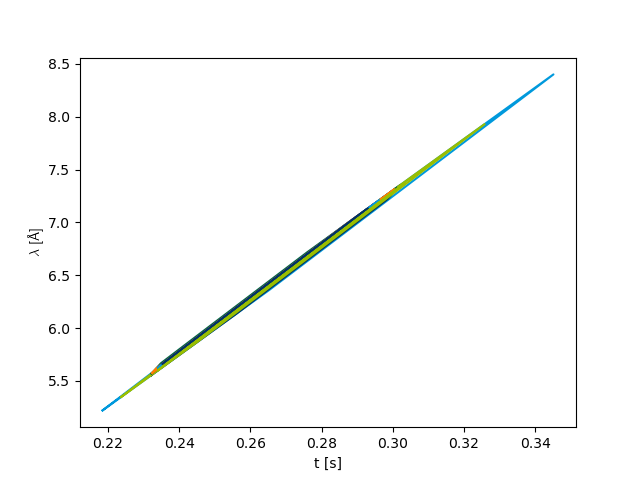

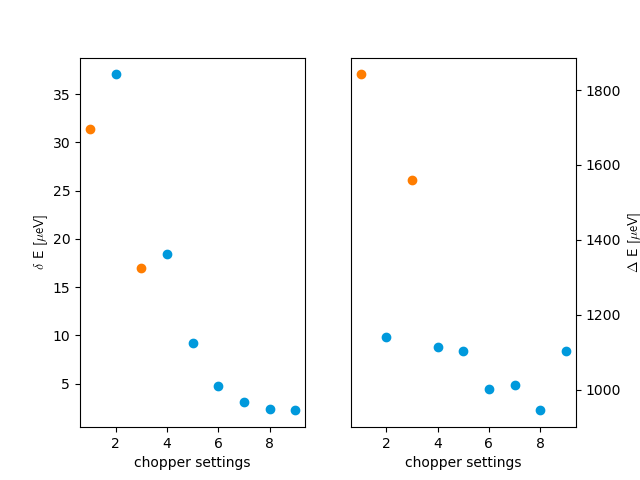

In [12]:
fig, ax = plt.subplots()
fig1, ax1 = plt.subplots(1,2)
for hi,at_sample in enumerate(ACdiagrams):
    y=at_sample[-1].subframes[0].wavelength.values
    x=at_sample[-1].subframes[0].time.values
    draw_polygon(x, y, ax,label=f'condition {hi+1}')
    x0=(min(x)+max(x))/2
    intersectionpoints=np.array(vertical_line_polygon_intersections(x,y,x0))
    dE=neutron_energy_ueV(intersectionpoints)
    if hi==0 or hi==2:
        color=ESS_COLORS["orange"]
    else:
        color=ESS_COLORS["cyan"]
    ax1[0].plot(hi+1,max(dE)-min(dE),'o',color=color)
    DE=neutron_energy_ueV(y)
    ax1[1].plot(hi+1,max(DE)-min(DE),'o',color=color)
    saveddata['dE'].append(max(dE)-min(dE))
    saveddata['DE'].append(max(DE)-min(DE))
ax.set_xlabel('t [s]')
ax.set_ylabel(r'$ \lambda$ [\AA]', usetex=True)
ax1[0].set_ylabel(r'$\delta$ E [$\mu$eV]', usetex=True)
ax1[0].set_xlabel('chopper settings')
ax1[1].set_ylabel(r'$\Delta$ E [$\mu$eV]', usetex=True)
ax1[1].set_xlabel('chopper settings')
ax1[1].yaxis.set_label_position("right")
ax1[1].yaxis.tick_right()
fig1.savefig("resolution_maximumenergytransfer.pdf")

In [13]:
RunMcstas=False
if RunMcstas:
    instr=make()
    instr.settings(ncount=1e9,mpi=8)
    for condition in [9]: # range(9,10): # range(1,10):
        for params in [[0.8,0,10],[0.8,0,0]]:
            f_QE=params[0]
            f_tun=params[1]
            gamma=params[2]
            folderpath=f'condition{condition}/samples_fQE{f_QE}_ftun{f_tun}gamma{gamma}'
            start_time = time.time()
            instr.settings(output_path=folderpath)
            chopperfile=f'condition{condition}/choppersettings.cfg'
            chopperfile=str(Path(chopperfile).resolve())
            chopperfile = f'"{chopperfile}"'
            print(chopperfile)
            instr.set_parameters(f_QE=f_QE,f_tun=f_tun,gamma=gamma, chopperfile=chopperfile)
            try:
                data = instr.backengine()
            except:
                print('mcstas not fully run')
            print(f'Calculation for {folderpath} finished in {time.time() - start_time}s')

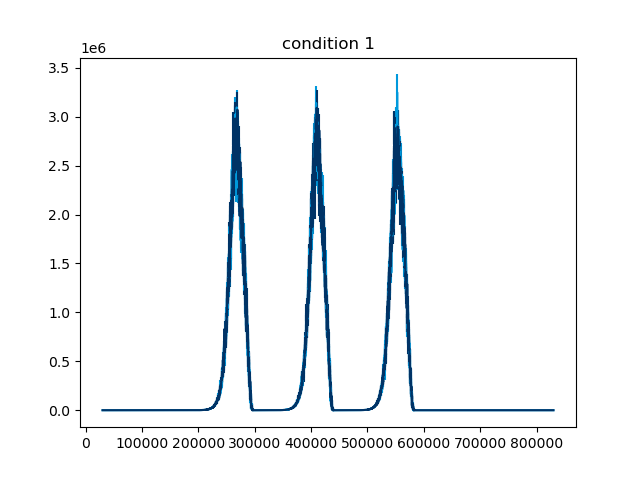

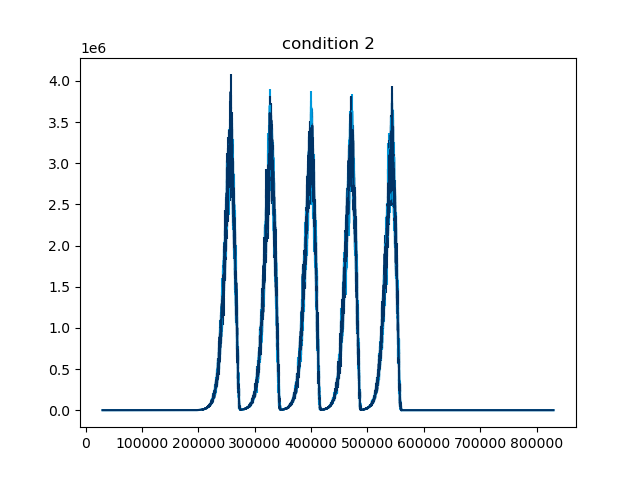

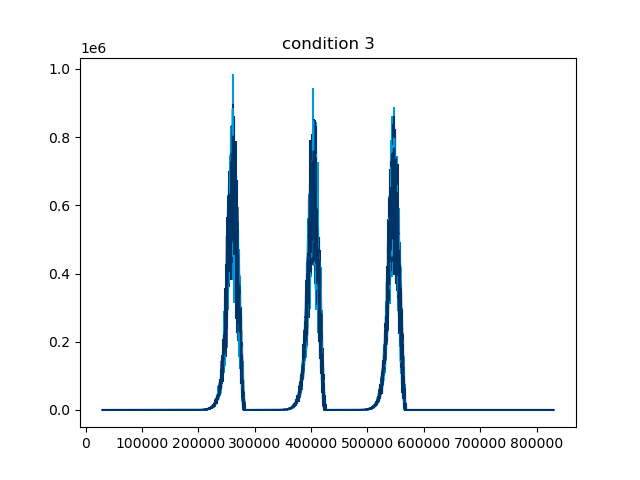

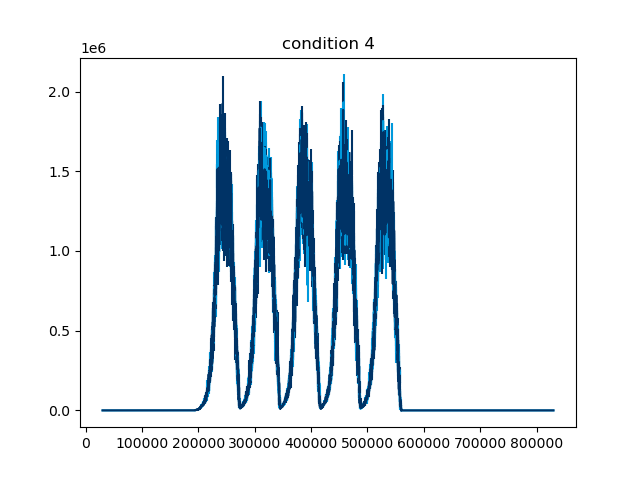

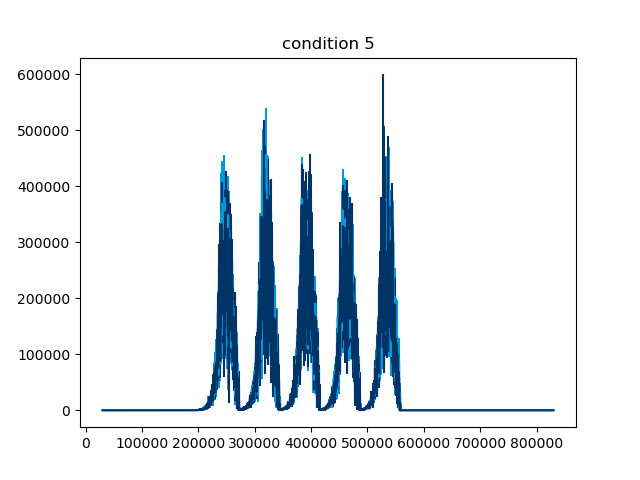

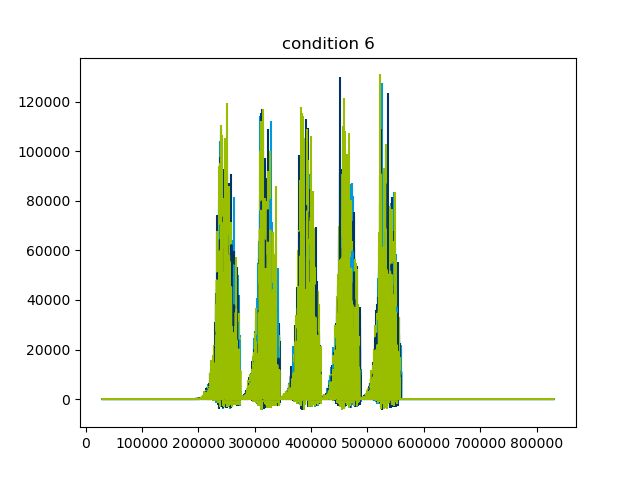

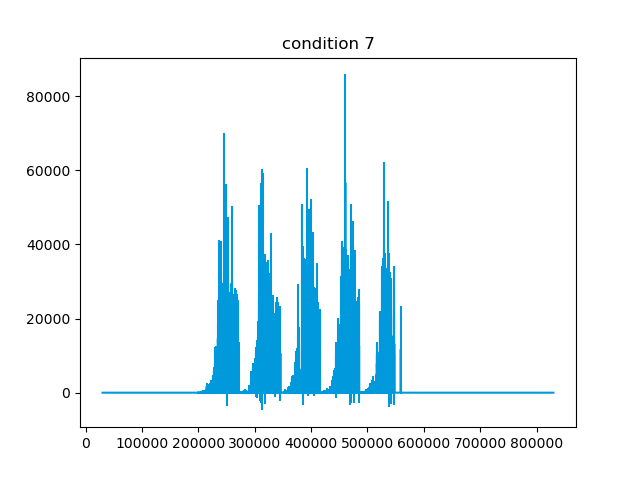

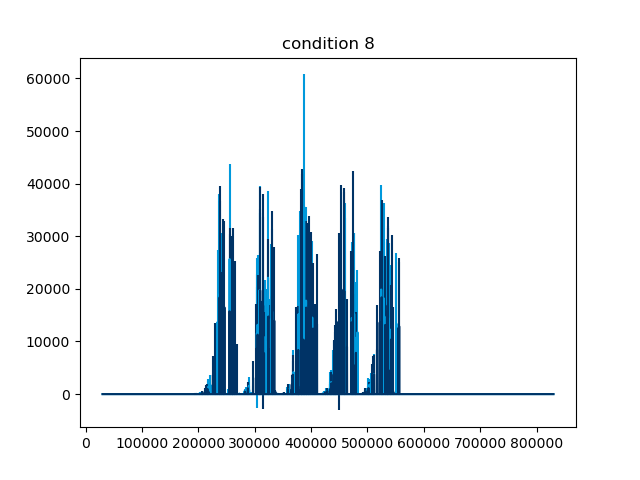

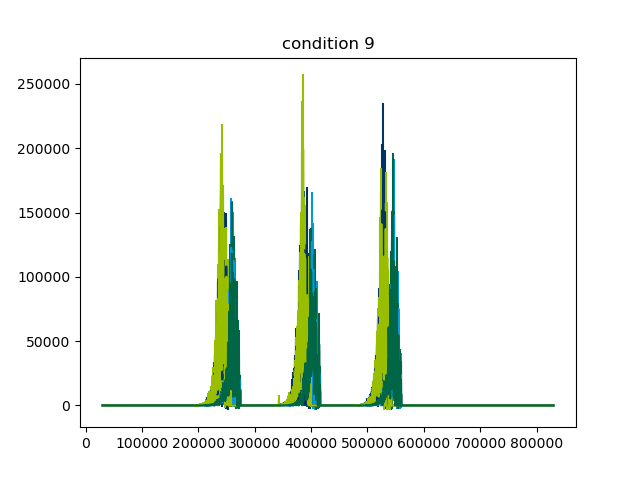

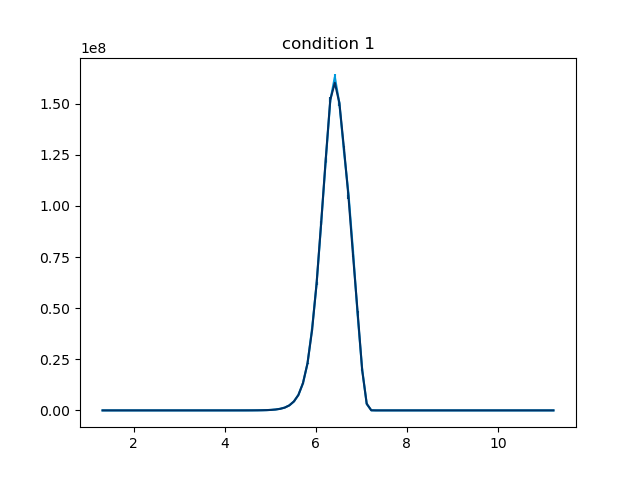

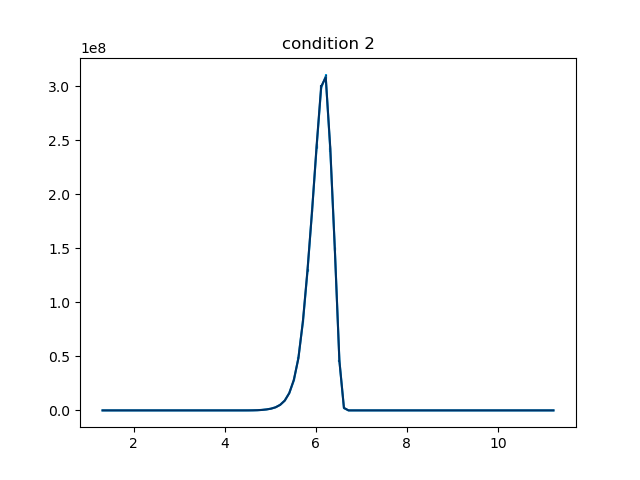

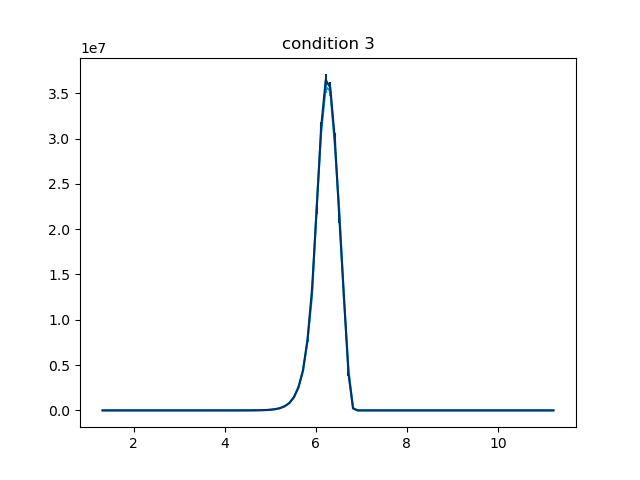

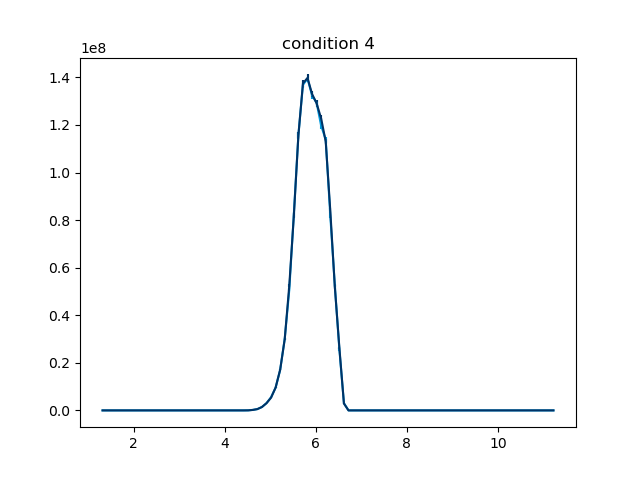

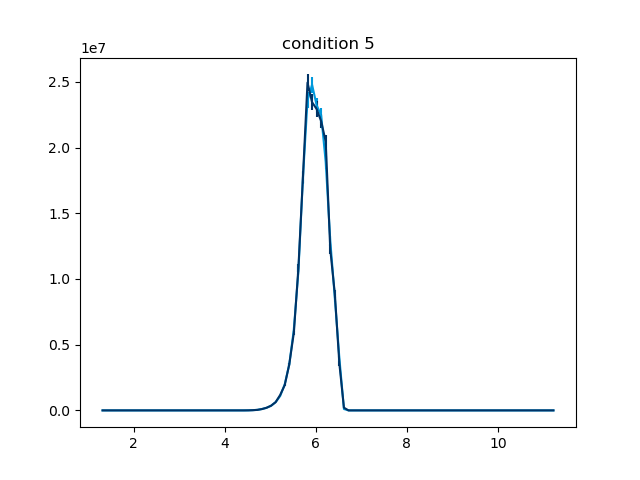

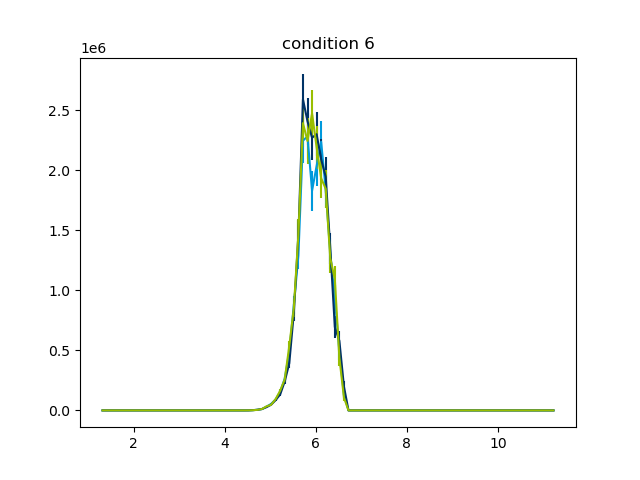

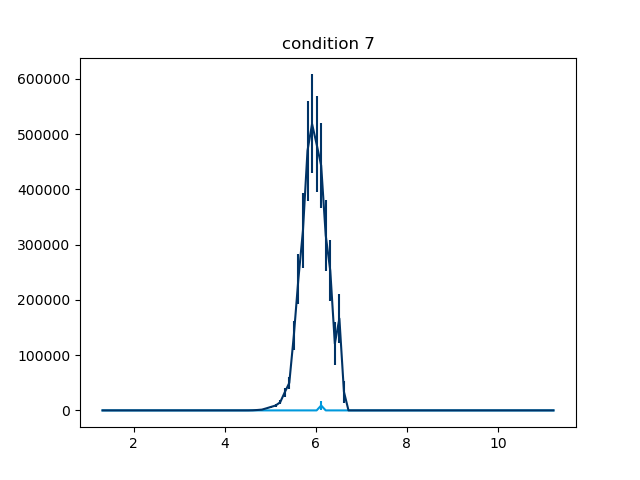

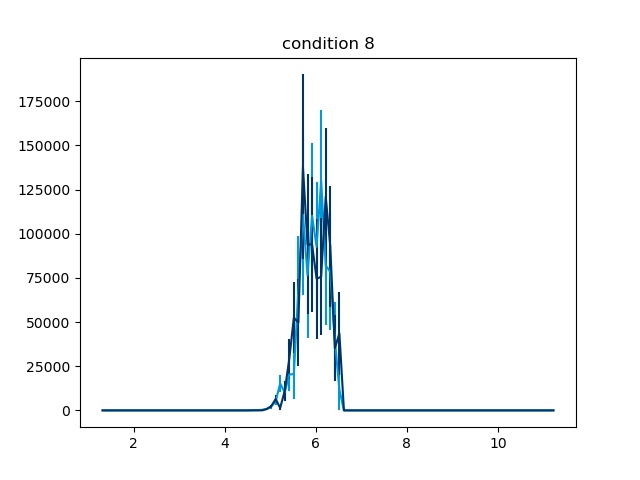

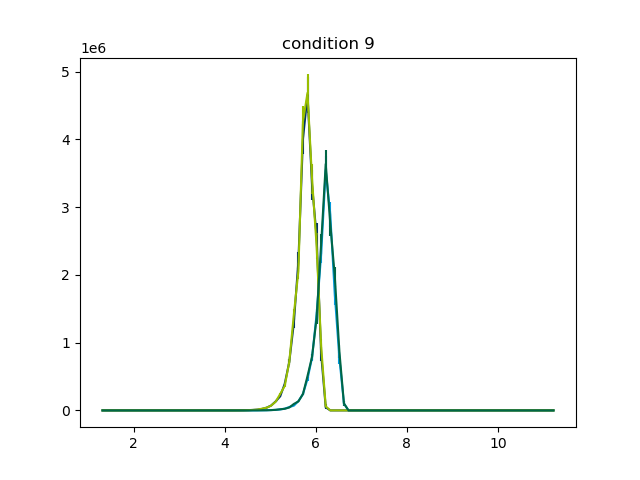

In [14]:
#plot WL BGAS
integratedneutrons=np.zeros(9)
for condition in range(1,10):
    base_dir = Path(f"condition{condition}")
    sample_folders = [p for p in base_dir.iterdir()
                      if p.is_dir() and p.name.startswith("sample")]
    fig,ax=plt.subplots()
    fig1,ax1=plt.subplots()
    for folder in sample_folders:
        try:
            data = np.loadtxt(str(folder)+"/between_guide_and_sample_wvl.dat", comments="#")
            integratedneutrons[condition-1]+=sum(data[:,1])
            ax.errorbar(data[:,0],data[:,1],data[:,2])
            ax.set_title(f"condition {condition}")
            fig.savefig(str(base_dir)+"/between_guide_and_sample_wvl.pdf")
            data1 = np.loadtxt(str(folder)+"/tof_BGAS.dat", comments="#")
            ax1.errorbar(data1[:,0],data1[:,1],data1[:,2])
            ax1.set_title(f"condition {condition}")
            fig1.savefig(str(base_dir)+"/tof_BGAS.pdf")
        except:
            pass
    plt.show()

/Users/christianbeck/tmp/ipykernel_6832/4038431289.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


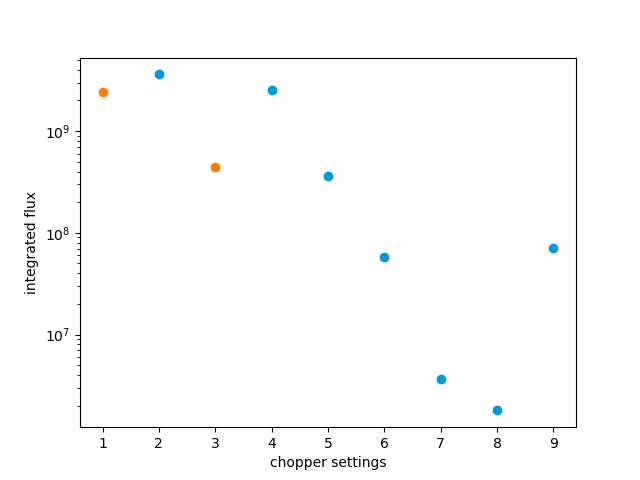

In [15]:
plt.figure()
for hi in range(9):
    if hi==0 or hi==2:
        color=ESS_COLORS["orange"]
    else:
        color=ESS_COLORS["cyan"]
    plt.semilogy(hi+1,integratedneutrons[hi],'o',color=color)
    saveddata['intflux'].append(integratedneutrons[hi])
plt.xlabel('chopper settings')
plt.ylabel('integrated flux')
plt.savefig('flux_choppersettings.pdf')

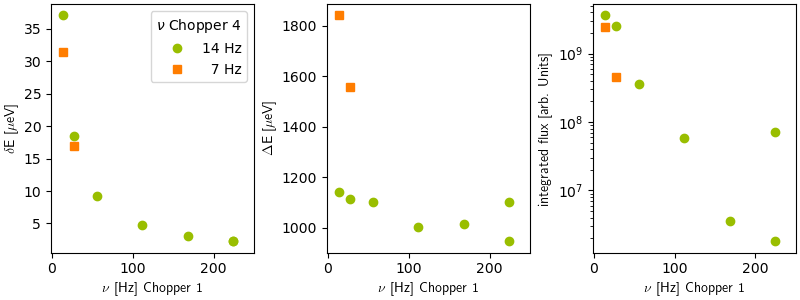

In [16]:
for x in saveddata:
    saveddata[x]=np.array(saveddata[x])
fig,axs=plt.subplots(1,3, constrained_layout=True,figsize=(8,3))
for hi,param in enumerate(['dE','DE','intflux']):
    axs[hi].plot(saveddata['frequencyCH1'][saveddata['frequencyCH4']==14],saveddata[param][saveddata['frequencyCH4']==14],'o',color=ESS_COLORS['grass'],label='14 Hz')
    axs[hi].plot(saveddata['frequencyCH1'][saveddata['frequencyCH4']==7],saveddata[param][saveddata['frequencyCH4']==7],'s',color=ESS_COLORS['orange'],label='  7 Hz')
axs[2].set_yscale('log')
for ax in axs:
    ax.set_xlim([-1,250])
    ax.set_xlabel(r'$\nu$ [Hz] Chopper 1',usetex=True)
leg=axs[0].legend(title=r'$\nu$ Chopper 4')
leg._legend_box.align = "right"
leg.get_frame().set_facecolor("none")
axs[0].set_ylabel(r'$\delta$E [$\mu$eV]',usetex=True)
axs[1].set_ylabel(r'$\Delta$E [$\mu$eV]',usetex=True)
axs[2].set_ylabel(r'integrated flux [arb. Units]',usetex=True)
fig.savefig('parameters_frequency.pdf', transparent=True)


In [17]:
saveddata[param]

array([2.42576785e+09, 3.60432355e+09, 4.47626897e+08, 2.50834492e+09,
       3.61976747e+08, 5.76644471e+07, 3.62901870e+06, 1.79751184e+06,
       7.09394456e+07])

In [24]:
res.detectors['sample'].data

<scipp.DataArray>
Dimensions: Sizes[pulse:5, event:10000000, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [2022.65, 2850.09, ..., 286966, 286246]
* distance                  float64              [m]  ()  162.5
* eto                       float64            [µs]  (pulse, event)  [58916.9, 35968.3, ..., 10240.3, 41391.1]
* id                          int64        <no unit>  (pulse, event)  [0, 1, ..., 49999998, 49999999]
* speed                     float64            [m/s]  (pulse, event)  [2856.17, 4906.66, ..., 1070.17, 3977.05]
* toa                       float64            [µs]  (pulse, event)  [58916.9, 35968.3, ..., 438812, 327105]
* tof                       float64            [µs]  (pulse, event)  [56894.3, 33118.2, ..., 151845, 40859.5]
* wavelength                float64             [Å]  (pulse, event)  [1.38508, 0.806258, ..., 3.69665, 0.994716]
Data:
                            float64         [counts]  (pulse, event)  [1, 1, ..., 1, 1]
Masks:
  blocked_by_others            bool        <no unit>  (pulse, event)  [True, True, ..., True, True]